# Extended Hertz Parameter Sweep

This notebook varies `adhesion_density` and `translational_drag` from the active PhysiCell XML configuration, runs the two-cell extended-Hertz setup, and plots the resulting overlap curves.

The overlap is computed as $\delta = R_1 + R_2 - d$, where $d$ is the center-to-center distance extracted from each saved snapshot.

In [2]:
from pathlib import Path
import shutil
import subprocess
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat

repo_root = Path('/home/tntiniak/Work/observatory_benchmark')
code_dir = repo_root / 'PhysiCell' / 'code'
config_path = code_dir / 'config' / 'PhysiCell_settings.xml'
results_dir = repo_root / 'PhysiCell' / 'results' / 'mechanics_pushing_extended_hertz'

config_path, results_dir

(PosixPath('/home/tntiniak/Work/observatory_benchmark/PhysiCell/code/config/PhysiCell_settings.xml'),
 PosixPath('/home/tntiniak/Work/observatory_benchmark/PhysiCell/results/mechanics_pushing_extended_hertz'))

In [3]:
def set_user_parameter(xml_path: Path, name: str, value: float) -> None:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    node = root.find(f'.//user_parameters/{name}')
    if node is None:
        raise KeyError(f'Could not find user parameter: {name}')
    node.text = str(value)
    tree.write(xml_path, encoding='utf-8', xml_declaration=False)


def clear_results(results_path: Path) -> None:
    if results_path.exists():
        shutil.rmtree(results_path)
    results_path.mkdir(parents=True, exist_ok=True)


def run_case(adhesion_density: float, translational_drag: float, verbose: bool = False) -> str:
    set_user_parameter(config_path, 'adhesion_density', adhesion_density)
    set_user_parameter(config_path, 'translational_drag', translational_drag)
    clear_results(results_dir)

    completed = subprocess.run(
        ['./project'],
        cwd=code_dir,
        check=True,
        capture_output=True,
        text=True,
    )
    if verbose:
        print(completed.stdout[-2000:])
    return completed.stdout


def load_overlap_curve(results_path: Path) -> pd.DataFrame:
    records = []
    for xml_path in sorted(results_path.glob('output*.xml')):
        root = ET.parse(xml_path).getroot()
        current_time = float(root.findtext('.//current_time'))
        mat_name = root.findtext('.//simplified_data/filename')
        if mat_name is None:
            raise ValueError(f'No cell data filename found in {xml_path}')

        cells = loadmat(results_path / mat_name)['cells']
        positions = cells[1:4, :].T
        radii = cells[37, :]
        if positions.shape[0] != 2:
            raise ValueError(f'Expected 2 cells, found {positions.shape[0]} in {mat_name}')

        distance = float(np.linalg.norm(positions[0] - positions[1]))
        overlap = float(radii[0] + radii[1] - distance)
        records.append({
            'time_min': current_time,
            'distance_um': distance,
            'radius_sum_um': float(radii[0] + radii[1]),
            'overlap_um': overlap,
        })

    frame = pd.DataFrame.from_records(records).sort_values('time_min').reset_index(drop=True)
    return frame

In [4]:
adhesion_values = [1e3, 1e5, 1e15]
drag_values = [0.02,0.2,0.4,0.5,0.6, 0.8, 0.1,1]

original_xml = config_path.read_text()
all_curves = []
summary_rows = []

try:
    for adhesion_density in adhesion_values:
        for translational_drag in drag_values:
            print(f'Running adhesion_density={adhesion_density:g}, translational_drag={translational_drag:g}')
            run_case(adhesion_density, translational_drag)
            curve = load_overlap_curve(results_dir)
            curve['adhesion_density'] = adhesion_density
            curve['translational_drag'] = translational_drag
            all_curves.append(curve)
            summary_rows.append({
                'adhesion_density': adhesion_density,
                'translational_drag': translational_drag,
                'initial_overlap_um': curve['overlap_um'].iloc[0],
                'final_overlap_um': curve['overlap_um'].iloc[-1],
                'max_overlap_um': curve['overlap_um'].max(),
            })
finally:
    config_path.write_text(original_xml)

curves = pd.concat(all_curves, ignore_index=True)
summary = pd.DataFrame(summary_rows).sort_values(['adhesion_density', 'translational_drag']).reset_index(drop=True)
summary

Running adhesion_density=1000, translational_drag=0.02
Running adhesion_density=1000, translational_drag=0.2
Running adhesion_density=1000, translational_drag=0.4
Running adhesion_density=1000, translational_drag=0.5
Running adhesion_density=1000, translational_drag=0.6
Running adhesion_density=1000, translational_drag=0.8
Running adhesion_density=1000, translational_drag=0.1
Running adhesion_density=1000, translational_drag=1
Running adhesion_density=100000, translational_drag=0.02
Running adhesion_density=100000, translational_drag=0.2
Running adhesion_density=100000, translational_drag=0.4
Running adhesion_density=100000, translational_drag=0.5
Running adhesion_density=100000, translational_drag=0.6
Running adhesion_density=100000, translational_drag=0.8
Running adhesion_density=100000, translational_drag=0.1
Running adhesion_density=100000, translational_drag=1
Running adhesion_density=1e+15, translational_drag=0.02
Running adhesion_density=1e+15, translational_drag=0.2
Running adh

,adhesion_density,translational_drag,initial_overlap_um,final_overlap_um,max_overlap_um
0,1.000000e+03,0.02,1.000008,0.000032,1.000008
1,1.000000e+03,0.10,1.000008,0.000095,1.000008
2,1.000000e+03,0.20,1.000008,0.000372,1.000008
3,1.000000e+03,0.40,1.000008,0.001433,1.000008
4,1.000000e+03,0.50,1.000008,0.002197,1.000008
5,1.000000e+03,0.60,1.000008,0.003106,1.000008
6,1.000000e+03,0.80,1.000008,0.005322,1.000008
7,1.000000e+03,1.00,1.000008,0.008020,1.000008
8,1.000000e+05,0.02,1.000008,0.000032,1.000008
9,1.000000e+05,0.10,1.000008,0.000095,1.000008


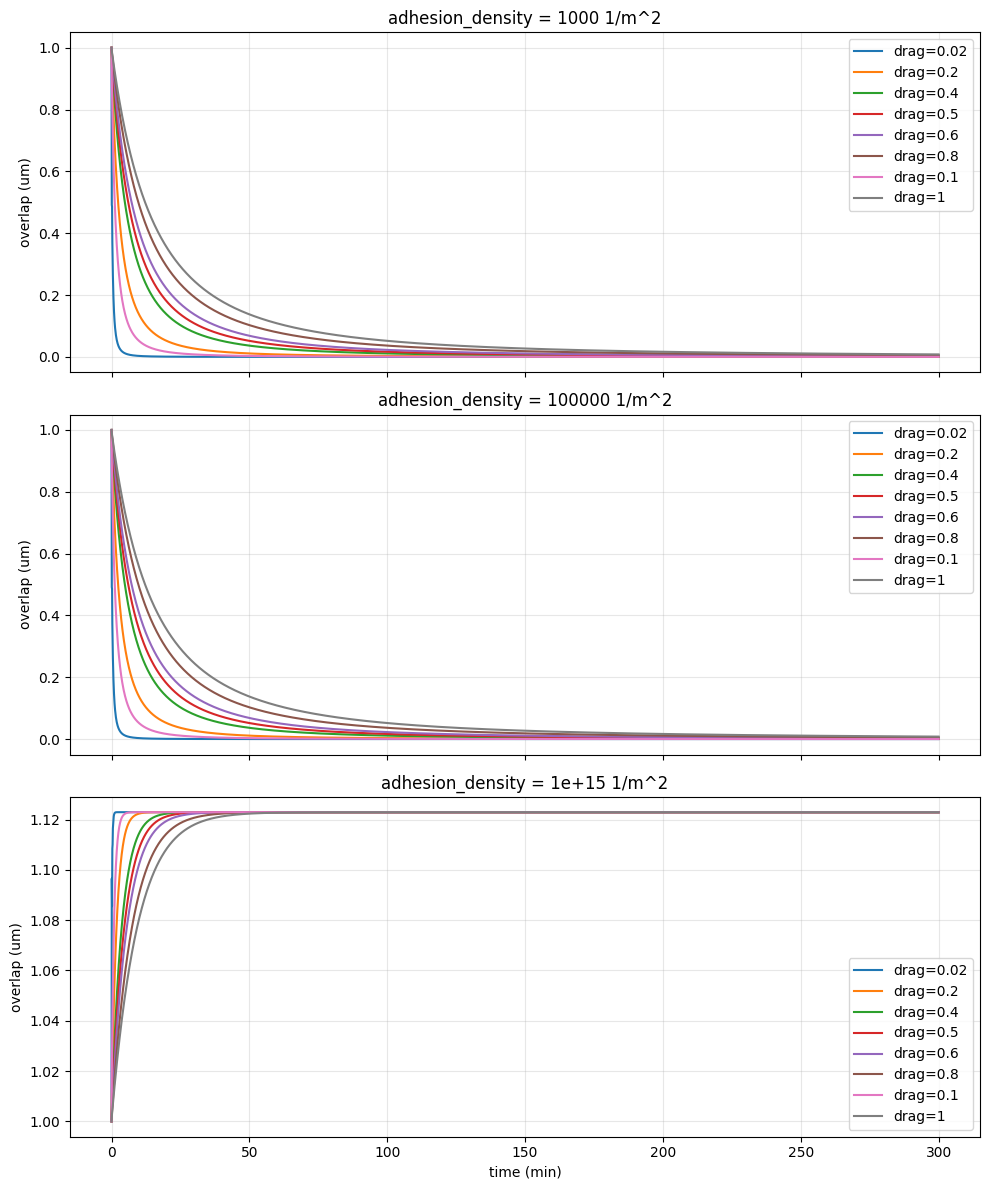

In [5]:
fig, axes = plt.subplots(len(adhesion_values), 1, figsize=(10, 4 * len(adhesion_values)), sharex=True)
if len(adhesion_values) == 1:
    axes = [axes]

for ax, adhesion_density in zip(axes, adhesion_values):
    subset = curves[curves['adhesion_density'] == adhesion_density]
    for translational_drag in drag_values:
        curve = subset[subset['translational_drag'] == translational_drag]
        ax.plot(curve['time_min'], curve['overlap_um'], label=f'drag={translational_drag:g}')
    ax.set_title(f'adhesion_density = {adhesion_density:g} 1/m^2')
    ax.set_ylabel('overlap (um)')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('time (min)')
plt.tight_layout()
plt.show()

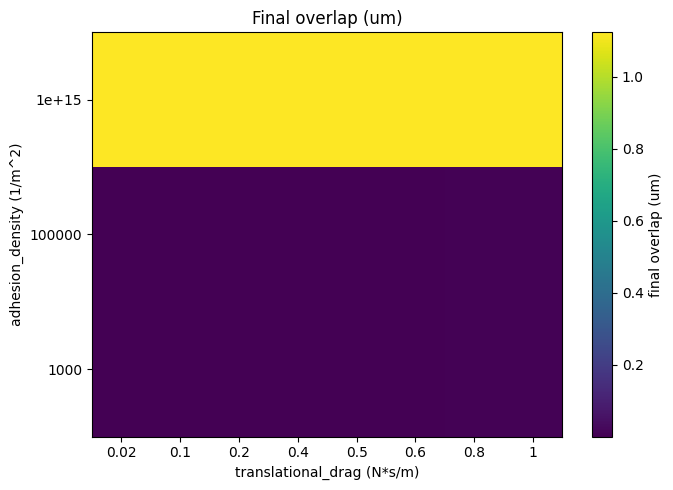

In [6]:
pivot = summary.pivot(index='adhesion_density', columns='translational_drag', values='final_overlap_um')
fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{value:g}' for value in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{value:g}' for value in pivot.index])
ax.set_xlabel('translational_drag (N*s/m)')
ax.set_ylabel('adhesion_density (1/m^2)')
ax.set_title('Final overlap (um)')
fig.colorbar(image, ax=ax, label='final overlap (um)')
plt.tight_layout()
plt.show()

## Comparison with Analytical Reference



This section imports the analytical equilibrium results from the reference notebook instead of recomputing them here. It then compares those imported reference values with the final state reached in each PhysiCell run.



The comparison uses the adhesion densities defined in the reference notebook. For each adhesion density, the analytical equilibrium is independent of translational drag, so the drag should only affect how fast the system relaxes, not the final force-balance state.

Initial overlap delta_0 = 1.000000 um
Effective radius R_tilde = 2.500000 um
Initial force F(delta_0) = -0.107307 nN
Equilibrium overlap delta_eq = 1.122915 um
Equilibrium distance d_eq = 8.877085 um


,adhesion_density_m^-2,gamma_J_per_m^2,delta_eq_um,d_eq_um
0,1e+15,8.556000e-05,1.122565,8.877435
1,1e+05,8.556000e-15,0.000000,10.000000


,adhesion_density,translational_drag,simulated_final_distance_um,simulated_final_overlap_um,gamma_J_per_m^2,analytical_delta_eq_um,analytical_d_eq_um,overlap_error_um,distance_error_um
0,1e+05,0.02,9.999976,0.000032,8.556000e-15,0.000000,10.000000,0.000031,-0.000023
1,1e+05,0.1,9.999913,0.000095,8.556000e-15,0.000000,10.000000,0.000095,-0.000087
2,1e+05,0.2,9.999636,0.000372,8.556000e-15,0.000000,10.000000,0.000372,-0.000364
3,1e+05,0.4,9.998575,0.001433,8.556000e-15,0.000000,10.000000,0.001433,-0.001425
4,1e+05,0.5,9.997810,0.002197,8.556000e-15,0.000000,10.000000,0.002197,-0.002189
5,1e+05,0.6,9.996902,0.003106,8.556000e-15,0.000000,10.000000,0.003106,-0.003098
6,1e+05,0.8,9.994686,0.005322,8.556000e-15,0.000000,10.000000,0.005322,-0.005314
7,1e+05,1,9.991987,0.008020,8.556000e-15,0.000000,10.000000,0.008020,-0.008012
8,1e+15,0.02,8.877044,1.122964,8.556000e-05,1.122565,8.877435,0.000399,-0.000392
9,1e+15,0.1,8.877044,1.122964,8.556000e-05,1.122565,8.877435,0.000399,-0.000391


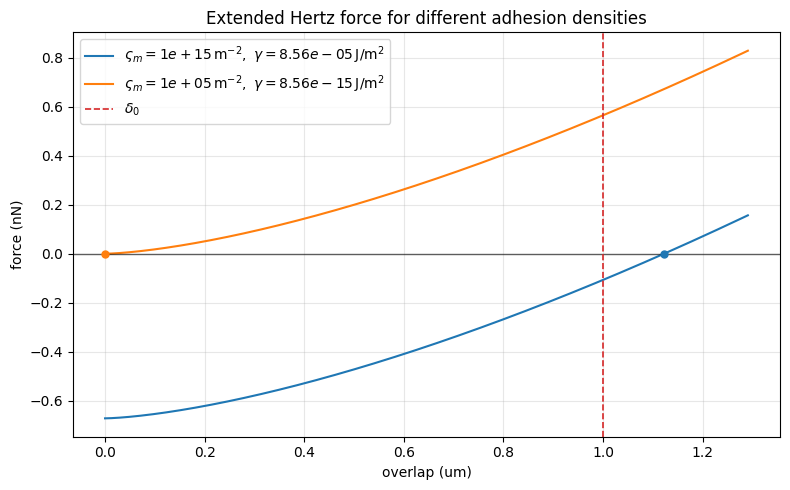

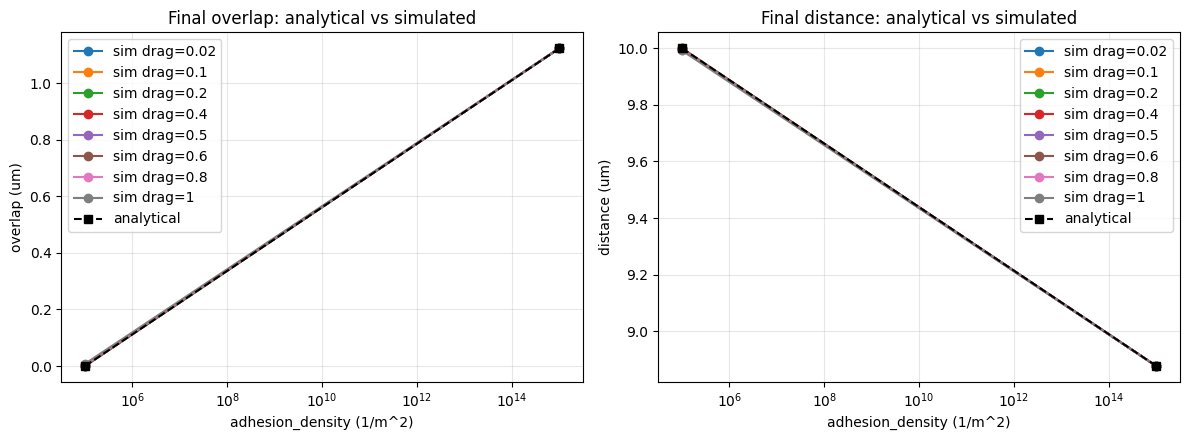

In [7]:
import json



reference_notebook_path = repo_root / 'analytical_solutions' / 'ExtendedHertz' / 'two_cell_relaxation_extended_hertz_reference.ipynb'



with reference_notebook_path.open() as handle:

    reference_notebook = json.load(handle)



reference_namespace = {

    'np': np,

    'pd': pd,

    'plt': plt,

}



original_show = plt.show

plt.show = lambda *args, **kwargs: None

try:

    for cell in reference_notebook['cells']:

        if cell.get('cell_type') != 'code':

            continue

        cell_source = ''.join(cell.get('source', []))

        if 'F_delta_0 = extended_hertz_force(delta_0)' in cell_source or 'equilibrium_summary = pd.DataFrame' in cell_source:

            exec(cell_source, reference_namespace)

finally:

    plt.show = original_show



analytical_reference = reference_namespace['equilibrium_summary'].rename(

    columns={

        'adhesion_density_m^-2': 'adhesion_density',

        'delta_eq_um': 'analytical_delta_eq_um',

        'd_eq_um': 'analytical_d_eq_um',

    }

)[['adhesion_density', 'gamma_J_per_m^2', 'analytical_delta_eq_um', 'analytical_d_eq_um']]



final_states = (

    curves.sort_values('time_min')

    .groupby(['adhesion_density', 'translational_drag'], as_index=False)

    .tail(1)[['adhesion_density', 'translational_drag', 'distance_um', 'overlap_um']]

    .rename(

        columns={

            'distance_um': 'simulated_final_distance_um',

            'overlap_um': 'simulated_final_overlap_um',

        }

    )

    .reset_index(drop=True)

)



comparison = final_states.merge(analytical_reference, on='adhesion_density', how='inner')

comparison['overlap_error_um'] = comparison['simulated_final_overlap_um'] - comparison['analytical_delta_eq_um']

comparison['distance_error_um'] = comparison['simulated_final_distance_um'] - comparison['analytical_d_eq_um']

comparison = comparison.sort_values(['adhesion_density', 'translational_drag']).reset_index(drop=True)



display(

    comparison.style.format(

        {

            'adhesion_density': '{:.0e}',

            'translational_drag': '{:g}',

            'gamma_J_per_m^2': '{:.6e}',

            'analytical_delta_eq_um': '{:.6f}',

            'simulated_final_overlap_um': '{:.6f}',

            'overlap_error_um': '{:.6f}',

            'analytical_d_eq_um': '{:.6f}',

            'simulated_final_distance_um': '{:.6f}',

            'distance_error_um': '{:.6f}',

        }

    )

)



fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)



for translational_drag in sorted(comparison['translational_drag'].unique()):

    subset = comparison[comparison['translational_drag'] == translational_drag]

    axes[0].plot(

        subset['adhesion_density'],

        subset['simulated_final_overlap_um'],

        marker='o',

        label=f'sim drag={translational_drag:g}'

    )

    axes[1].plot(

        subset['adhesion_density'],

        subset['simulated_final_distance_um'],

        marker='o',

        label=f'sim drag={translational_drag:g}'

    )



analytical_sorted = analytical_reference.sort_values('adhesion_density')

axes[0].plot(

    analytical_sorted['adhesion_density'],

    analytical_sorted['analytical_delta_eq_um'],

    color='black',

    linestyle='--',

    marker='s',

    label='analytical'

)

axes[1].plot(

    analytical_sorted['adhesion_density'],

    analytical_sorted['analytical_d_eq_um'],

    color='black',

    linestyle='--',

    marker='s',

    label='analytical'

)



for ax, ylabel, title in zip(

    axes,

    ['overlap (um)', 'distance (um)'],

    ['Final overlap: analytical vs simulated', 'Final distance: analytical vs simulated']

):

    ax.set_xscale('log')

    ax.set_xlabel('adhesion_density (1/m^2)')

    ax.set_ylabel(ylabel)

    ax.set_title(title)

    ax.grid(True, alpha=0.3)

    ax.legend()



plt.tight_layout()

plt.show()

## Single-Case Comparison: $\sigma_m = 10^{15}\,\mathrm{m}^{-2}$ and drag $=1$



This plot compares the simulated overlap trajectory for adhesion density $10^{15}\,\mathrm{m}^{-2}$ and translational drag $1$ against the analytical initial overlap and analytical equilibrium overlap.

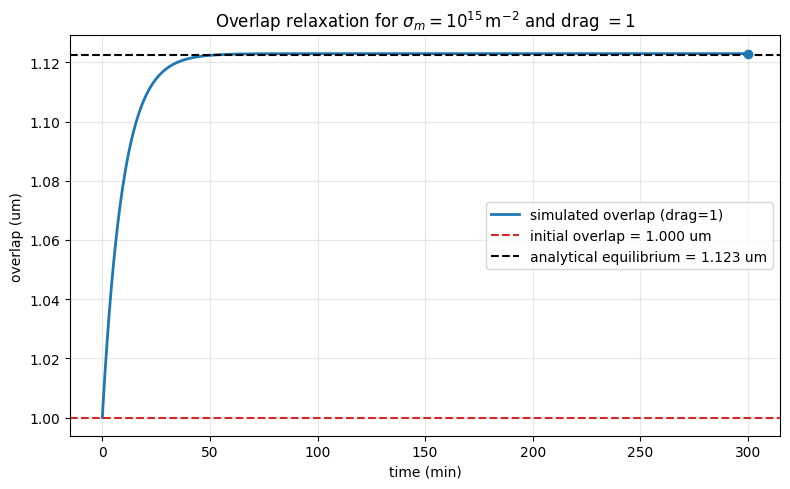

In [8]:
selected_adhesion_density = 1e15

selected_drag = 1



selected_curve = curves[

    (curves['adhesion_density'] == selected_adhesion_density)

    & (curves['translational_drag'] == selected_drag)

]

if selected_curve.empty:

    raise ValueError('No simulation curve found for adhesion_density=1e15 and translational_drag=1')



selected_reference = analytical_reference[

    analytical_reference['adhesion_density'] == selected_adhesion_density

]

if selected_reference.empty:

    raise ValueError('No analytical reference found for adhesion_density=1e15')



initial_overlap_um = float(selected_curve['overlap_um'].iloc[0])

analytical_equilibrium_overlap_um = float(selected_reference['analytical_delta_eq_um'].iloc[0])



fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(

    selected_curve['time_min'],

    selected_curve['overlap_um'],

    color='tab:blue',

    linewidth=2.0,

    label='simulated overlap (drag=1)'

)

ax.axhline(

    initial_overlap_um,

    color='tab:red',

    linestyle='--',

    linewidth=1.5,

    label=f'initial overlap = {initial_overlap_um:.3f} um'

)

ax.axhline(

    analytical_equilibrium_overlap_um,

    color='black',

    linestyle='--',

    linewidth=1.5,

    label=f'analytical equilibrium = {analytical_equilibrium_overlap_um:.3f} um'

)

ax.scatter(

    [selected_curve['time_min'].iloc[-1]],

    [selected_curve['overlap_um'].iloc[-1]],

    color='tab:blue',

    zorder=3,

)

ax.set_xlabel('time (min)')

ax.set_ylabel('overlap (um)')

ax.set_title(r'Overlap relaxation for $\sigma_m = 10^{15}\,\mathrm{m}^{-2}$ and drag $=1$')

ax.grid(True, alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()

## Drag-by-Drag Trajectory Comparison with `mechanics_pushing_extended_hertz`

This section imports the analytical ODE setup directly from `ResultAnalysis/mechanics_pushing_extended_hertz.ipynb` and evaluates it for every translational drag in this sweep.

Because that analytical notebook is parameterized for the $\sigma_m = 10^{15}\,\mathrm{m}^{-2}$ case, the comparison below is restricted to that adhesion density and produces one simulated-versus-analytical overlap plot per drag.

For each drag, the notebook also computes the integral of the absolute difference between the simulated and analytical overlap curves over time and summarizes those values in a heatmap.

/tmp/ipykernel_389466/2154534947.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_between_curves_um_min = np.trapz(absolute_difference_um, simulated_time_min)


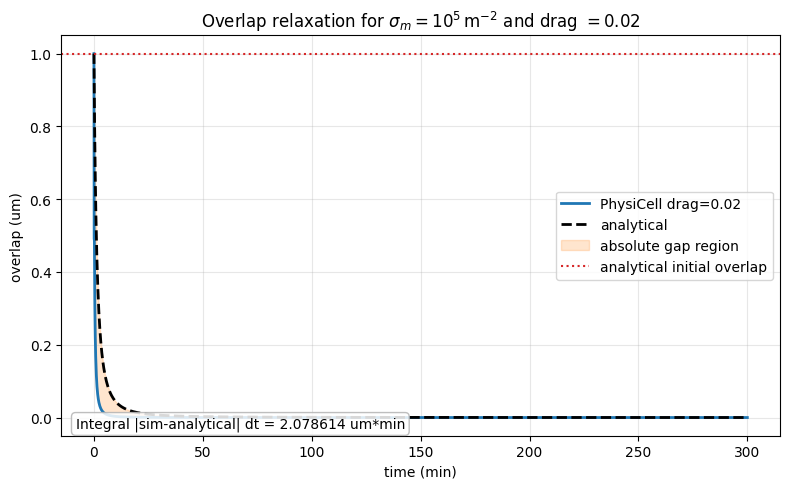

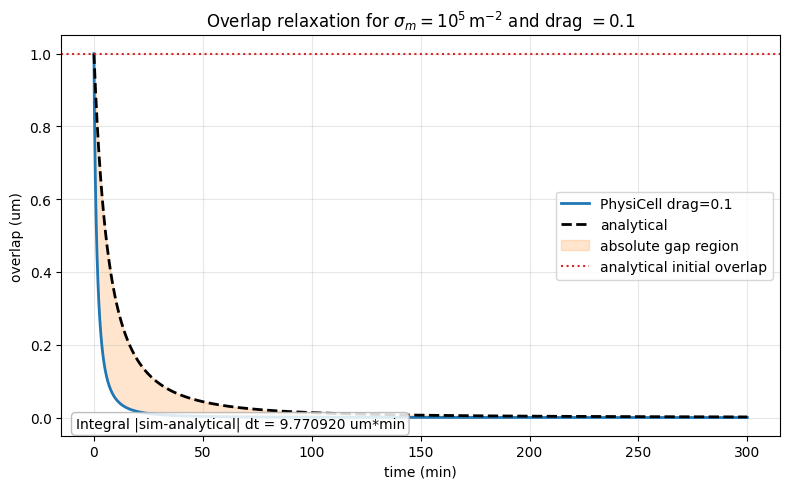

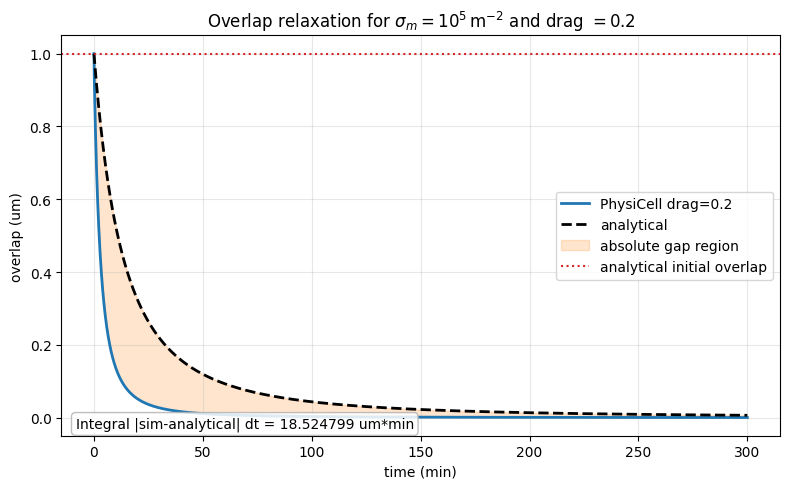

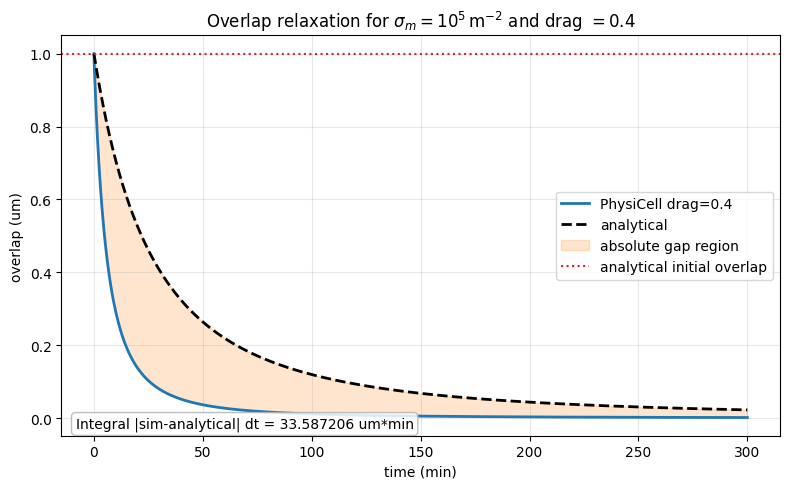

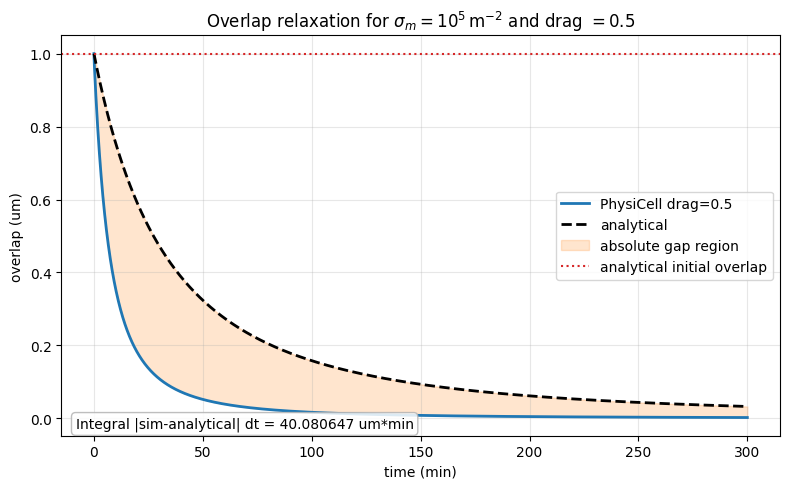

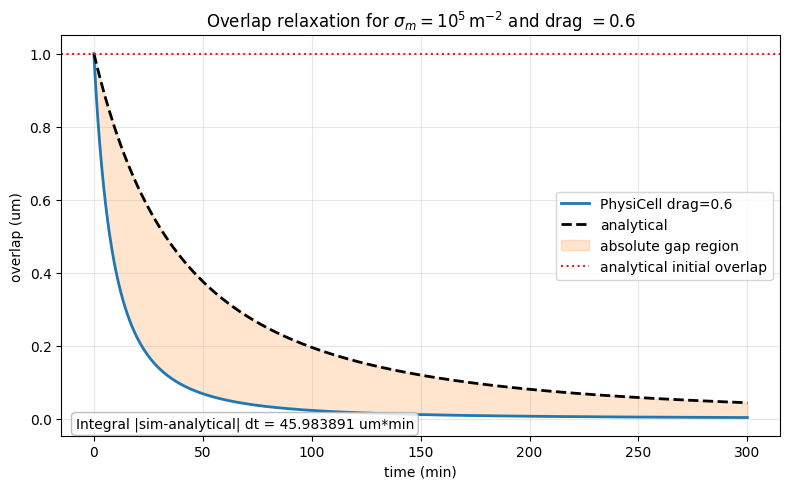

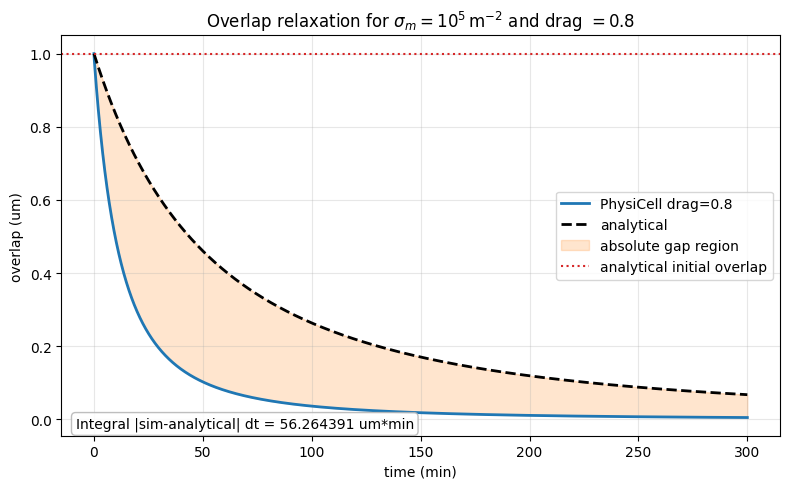

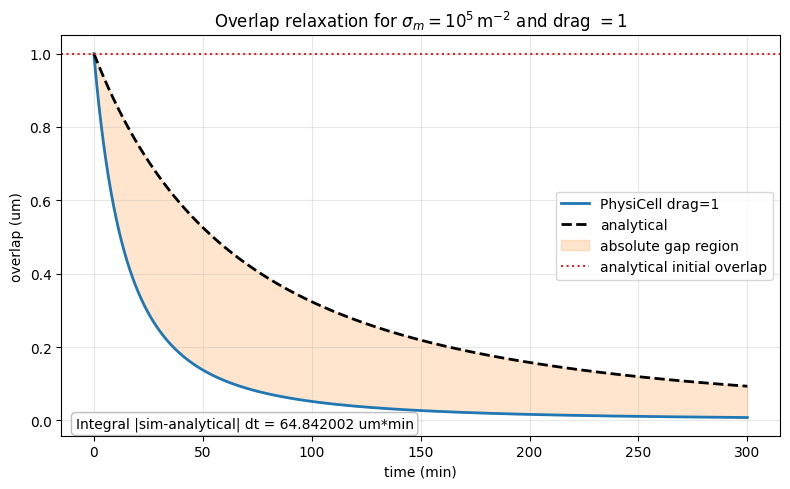

,adhesion_density,translational_drag,area_between_curves_um_min
0,100000.0,0.02,2.078614
1,100000.0,0.10,9.770920
2,100000.0,0.20,18.524799
3,100000.0,0.40,33.587206
4,100000.0,0.50,40.080647
5,100000.0,0.60,45.983891
6,100000.0,0.80,56.264391
7,100000.0,1.00,64.842002


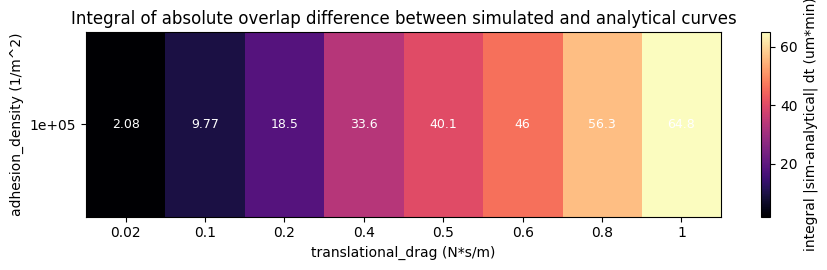

In [10]:
import json
from scipy.integrate import solve_ivp

analytical_drag_notebook_path = repo_root / 'ResultAnalysis' / 'mechanics_pushing_extended_hertz.ipynb'

with analytical_drag_notebook_path.open() as handle:
    analytical_drag_notebook = json.load(handle)

analytical_drag_namespace = {
    'np': np,
    'pd': pd,
    'plt': plt,
}

for cell in analytical_drag_notebook['cells']:
    if cell.get('cell_type') != 'code':
        continue
    cell_source = ''.join(cell.get('source', []))
    if 'def force_eHertz(delta):' in cell_source or 'delta_0 = 1e-6' in cell_source:
        exec(cell_source, analytical_drag_namespace)

comparison_adhesion_density = 1e5
trajectory_integral_rows = []

comparison_curves = curves[curves['adhesion_density'] == comparison_adhesion_density].copy()
if comparison_curves.empty:
    raise ValueError('No simulation curves found for adhesion_density=1e5')

for translational_drag in sorted(comparison_curves['translational_drag'].unique()):
    simulated_curve = (
        comparison_curves[comparison_curves['translational_drag'] == translational_drag]
        .sort_values('time_min')
        .reset_index(drop=True)
    )

    analytical_solution = solve_ivp(
        analytical_drag_namespace['ode_system'],
        analytical_drag_namespace['t_span'],
        [analytical_drag_namespace['delta_0']],
        args=(translational_drag,),
        t_eval=analytical_drag_namespace['t_eval'],
        method='RK45',
        rtol=1e-8,
        atol=1e-14,
    )

    analytical_time_min = analytical_solution.t / 60.0
    analytical_overlap_um = analytical_solution.y[0] / 1e-6

    simulated_time_min = simulated_curve['time_min'].to_numpy()
    simulated_overlap_um = simulated_curve['overlap_um'].to_numpy()
    analytical_on_sim_grid_um = np.interp(
        simulated_time_min,
        analytical_time_min,
        analytical_overlap_um,
    )
    absolute_difference_um = np.abs(simulated_overlap_um - analytical_on_sim_grid_um)
    area_between_curves_um_min = np.trapz(absolute_difference_um, simulated_time_min)
    trajectory_integral_rows.append({
        'adhesion_density': comparison_adhesion_density,
        'translational_drag': translational_drag,
        'area_between_curves_um_min': area_between_curves_um_min,
    })

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(
        simulated_time_min,
        simulated_overlap_um,
        color='tab:blue',
        linewidth=2.0,
        label=f'PhysiCell drag={translational_drag:g}'
    )
    ax.plot(
        analytical_time_min,
        analytical_overlap_um,
        color='black',
        linestyle='--',
        linewidth=2.0,
        label='analytical'
    )
    ax.fill_between(
        simulated_time_min,
        simulated_overlap_um,
        analytical_on_sim_grid_um,
        color='tab:orange',
        alpha=0.2,
        label='absolute gap region'
    )
    ax.axhline(
        analytical_drag_namespace['delta_0'] / 1e-6,
        color='tab:red',
        linestyle=':',
        linewidth=1.5,
        label='analytical initial overlap'
    )
    ax.set_xlabel('time (min)')
    ax.set_ylabel('overlap (um)')
    ax.set_title(
        r'Overlap relaxation for $\sigma_m = 10^{5}\,\mathrm{m}^{-2}$ '
        + f'and drag $={translational_drag:g}$'
    )
    ax.text(
        0.02,
        0.02,
        f'Integral |sim-analytical| dt = {area_between_curves_um_min:.6f} um*min',
        transform=ax.transAxes,
        fontsize=10,
        bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85, 'edgecolor': '0.7'}
    )
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

trajectory_integrals = pd.DataFrame(trajectory_integral_rows).sort_values('translational_drag').reset_index(drop=True)
display(trajectory_integrals)

integral_pivot = trajectory_integrals.pivot(
    index='adhesion_density',
    columns='translational_drag',
    values='area_between_curves_um_min',
)

fig, ax = plt.subplots(figsize=(9, 2.8))
image = ax.imshow(integral_pivot.values, aspect='auto', origin='lower', cmap='magma')
ax.set_xticks(range(len(integral_pivot.columns)))
ax.set_xticklabels([f'{value:g}' for value in integral_pivot.columns])
ax.set_yticks(range(len(integral_pivot.index)))
ax.set_yticklabels([f'{value:.0e}' for value in integral_pivot.index])
ax.set_xlabel('translational_drag (N*s/m)')
ax.set_ylabel('adhesion_density (1/m^2)')
ax.set_title('Integral of absolute overlap difference between simulated and analytical curves')

for row_idx in range(integral_pivot.shape[0]):
    for col_idx in range(integral_pivot.shape[1]):
        value = integral_pivot.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{value:.3g}', ha='center', va='center', color='white', fontsize=9)

fig.colorbar(image, ax=ax, label='integral |sim-analytical| dt (um*min)')
plt.tight_layout()
plt.show()
